# Editions per project (Q3)

How many **artworks (editions)** were actually minted per fxhash project.

- **project** = one generative program (one row here);
- **edition** / *iteration* = one minted output of that program (an NFT).

Two columns matter: `supply` (the edition cap the artist set) and
`iterations_count` (how many were actually minted). All numbers come from
`data/fxhash_tokens.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMG = Path("docs/img")
IMG.mkdir(parents=True, exist_ok=True)

# One row per project. supply = edition cap; iterations_count = editions minted.
df = pd.read_csv("data/fxhash_tokens.csv")
df["supply"] = pd.to_numeric(df["supply"], errors="coerce")
df["minted"] = pd.to_numeric(df["iterations_count"], errors="coerce")
df = df.dropna(subset=["minted"])
len(df)

28124

## Headline numbers

In [2]:
projects = len(df)
total_minted = int(df["minted"].sum())
never = int((df["minted"] == 0).sum())
sold = df[df["supply"] > 0]
sold_out = int((sold["minted"] >= sold["supply"]).sum())

print(f"projects:                 {projects:,}")
print(f"total editions minted:    {total_minted:,}")
print(f"median per project:       {df['minted'].median():.0f}")
print(f"mean per project:         {df['minted'].mean():.1f}")
print(f"max (single project):     {int(df['minted'].max()):,}")
print(f"projects never minted:    {never:,}")
print(f"projects that sold out:   {sold_out:,} of {len(sold):,} ({100*sold_out/len(sold):.0f}%)")

projects:                 28,124
total editions minted:    2,704,476
median per project:       21
mean per project:         96.2
max (single project):     323,264
projects never minted:    1,124
projects that sold out:   19,561 of 27,798 (70%)


## Distribution: editions per project

Values span 0 to 300k+, so the x-axis is logarithmic.

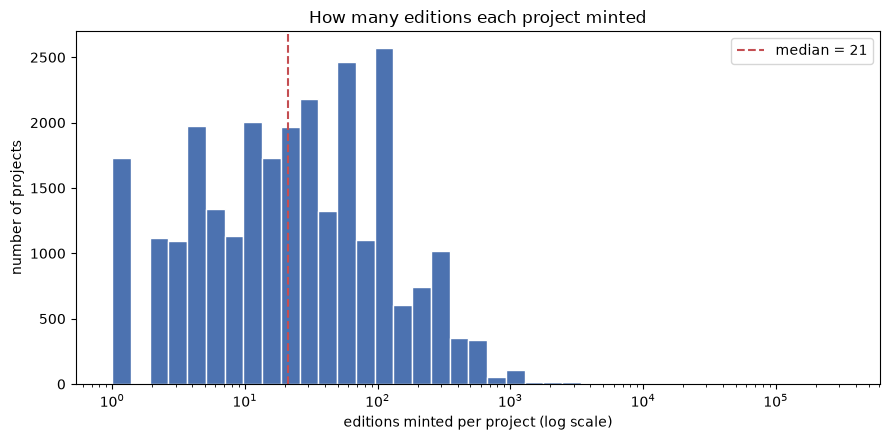

In [3]:
# Log-spaced bins because a few projects have 100k+ editions and most have <50.
pos = df["minted"][df["minted"] > 0]
bins = np.logspace(0, np.log10(pos.max()), 40)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(pos, bins=bins, color="#4c72b0", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("editions minted per project (log scale)")
ax.set_ylabel("number of projects")
ax.set_title("How many editions each project minted")
ax.axvline(df["minted"].median(), color="#c44e52", ls="--",
           label=f"median = {df['minted'].median():.0f}")
ax.legend()
fig.tight_layout()
fig.savefig(IMG / "editions_distribution.png", dpi=110)
plt.show()

## Top projects by editions minted

A handful of blockbusters account for a large share of all editions.

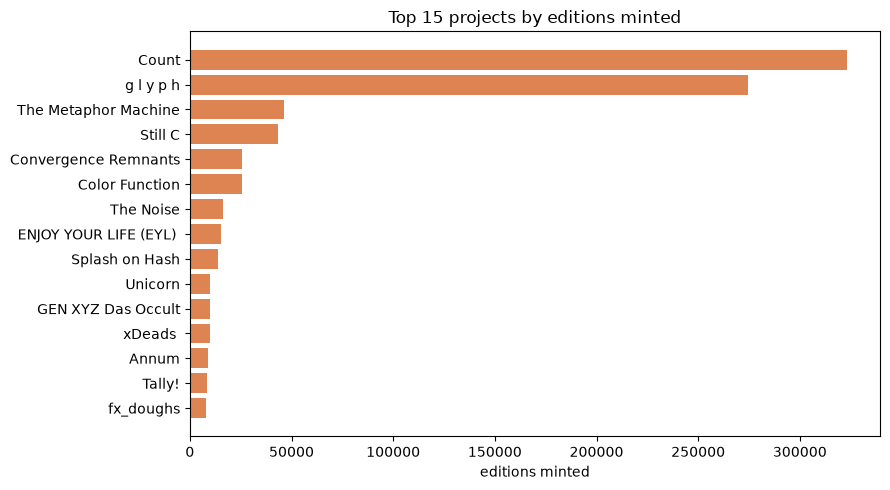

'                  name            version   minted\n                 Count   fxhash 2.0 (EVM) 323264.0\n             g l y p h   fxhash 2.0 (EVM) 274464.0\n  The Metaphor Machine   fxhash 2.0 (EVM)  46074.0\n               Still C   fxhash 2.0 (EVM)  43540.0\n  Convergence Remnants   fxhash 2.0 (EVM)  25751.0\n        Color Function   fxhash 2.0 (EVM)  25649.0\n             The Noise   fxhash 2.0 (EVM)  16510.0\nENJOY YOUR LIFE (EYL)    fxhash 2.0 (EVM)  15200.0\n        Splash on Hash   fxhash 2.0 (EVM)  13723.0\n               Unicorn fxhash 1.0 (Tezos)  10000.0\n    GEN XYZ Das Occult fxhash 1.0 (Tezos)  10000.0\n               xDeads  fxhash 1.0 (Tezos)   9988.0\n                 Annum fxhash 1.0 (Tezos)   8710.0\n                Tally! fxhash 1.0 (Tezos)   8580.0\n             fx_doughs fxhash 1.0 (Tezos)   8008.0'

In [4]:
top = df.nlargest(15, "minted")[["name", "version", "minted"]][::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["name"], top["minted"], color="#dd8452")
ax.set_xlabel("editions minted")
ax.set_title("Top 15 projects by editions minted")
fig.tight_layout()
fig.savefig(IMG / "editions_top.png", dpi=110)
plt.show()
top[::-1].to_string(index=False)

## Minted vs supply cap (sell-through)

Points on the diagonal sold out; points below it kept unsold edition slots.

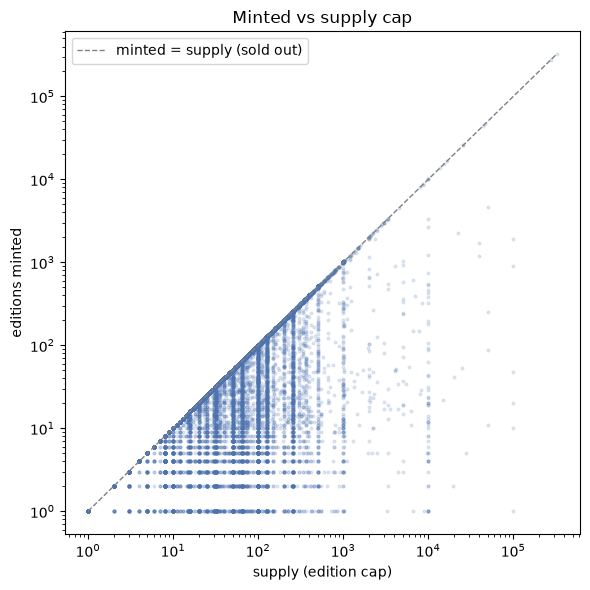

In [5]:
s = df[(df["supply"] > 0) & (df["minted"] > 0)]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(s["supply"], s["minted"], s=4, alpha=0.15, color="#4c72b0")
lim = [1, float(s[["supply", "minted"]].max().max())]
ax.plot(lim, lim, "--", color="grey", lw=1, label="minted = supply (sold out)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("supply (edition cap)")
ax.set_ylabel("editions minted")
ax.set_title("Minted vs supply cap")
ax.legend()
fig.tight_layout()
fig.savefig(IMG / "editions_supply_vs_minted.png", dpi=110)
plt.show()

## By platform version

                    projects  total_editions  median
version                                             
fxhash 1.0 (Tezos)     27430       1845509.0    21.0
fxhash 2.0 (EVM)         694        858967.0    13.0


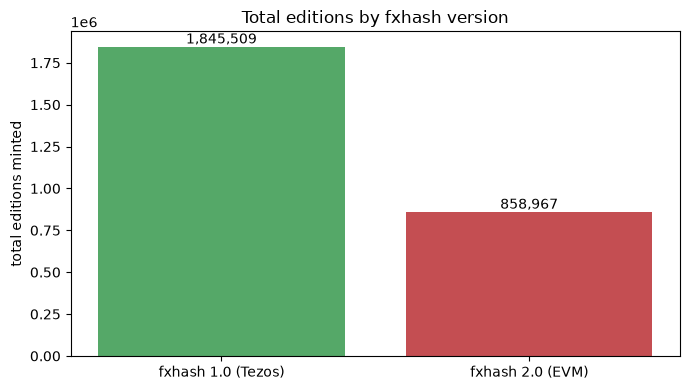

In [6]:
by = df.groupby("version")["minted"].agg(
    projects="count", total_editions="sum", median="median")
print(by)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by.index, by["total_editions"], color=["#55a868", "#c44e52"])
ax.set_ylabel("total editions minted")
ax.set_title("Total editions by fxhash version")
for i, v in enumerate(by["total_editions"]):
    ax.text(i, v, f"{int(v):,}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(IMG / "editions_by_version.png", dpi=110)
plt.show()